# 03 - Evaluation & Plots

Evaluate a completed run, compute the required metrics, and generate all five plots.

This notebook assumes you have already produced a run (e.g. via `python main.py --mode mock --run-id mock_demo` or notebook 02). Set `RUN_ID` accordingly.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath('..'))

from src.pipeline.evaluation import evaluate_run
from src.plotting import generate_all_plots
from src.config import RUNS_DIR

# Pick a run that exists under outputs/runs/.
available = [p.name for p in RUNS_DIR.iterdir() if p.is_dir()] if RUNS_DIR.exists() else []
print('Available runs:', available)
RUN_ID = 'mock_demo' if 'mock_demo' in available else (available[0] if available else 'mock_demo')
print('Using run:', RUN_ID)

Available runs: ['mock_demo', 'notebook_run']
Using run: mock_demo


In [2]:
df, metrics = evaluate_run(RUN_ID)
print(json.dumps(metrics, indent=2))

{
  "num_problems": 25,
  "overall_accuracy": 0.96,
  "improvement_rate": 0.36,
  "consensus_rate": 0.44,
  "judge_accuracy_when_disagreement": 0.875,
  "num_disagreement_problems": 8,
  "single_llm_baseline_accuracy": 0.5800000000000001,
  "single_llm_accuracy_by_model": {
    "gpt": 0.68,
    "claude": 0.68,
    "gemini": 0.52,
    "grok": 0.44
  },
  "simple_voting_baseline_accuracy": 0.8,
  "full_debate_system_accuracy": 0.96,
  "debate_accuracy_by_category": {
    "game_theory": 0.75,
    "logic_constraint": 1.0,
    "mathematical_reasoning": 1.0,
    "physics_science": 1.0
  }
}


In [3]:
# Peek at the per-problem results table.
df[['problem_id', 'category', 'debate_final_answer', 'debate_correct', 'voting_correct', 'consensus_type']].head(25)

,problem_id,category,debate_final_answer,debate_correct,voting_correct,consensus_type
0,game_001,game_theory,B,True,False,partial
1,game_002,game_theory,alternative_3,False,True,partial
2,game_003,game_theory,yes,True,True,partial
3,game_004,game_theory,1,True,True,full
4,logic_001,logic_constraint,knave,True,True,partial
5,logic_002,logic_constraint,B,True,True,full
6,logic_003,logic_constraint,B,True,True,full
7,logic_004,logic_constraint,30,True,True,partial
8,logic_005,logic_constraint,7.5,True,True,full
9,logic_006,logic_constraint,240,True,False,partial


## Generate and display all plots

In [4]:
paths = generate_all_plots(metrics)
for p in paths:
    print('saved', p)

saved C:\Users\PCZONE.GE\Desktop\LLM Final\outputs\plots\accuracy_comparison.png
saved C:\Users\PCZONE.GE\Desktop\LLM Final\outputs\plots\accuracy_by_category.png
saved C:\Users\PCZONE.GE\Desktop\LLM Final\outputs\plots\refinement_improvement.png
saved C:\Users\PCZONE.GE\Desktop\LLM Final\outputs\plots\consensus_rate.png
saved C:\Users\PCZONE.GE\Desktop\LLM Final\outputs\plots\judge_accuracy_disagreement.png


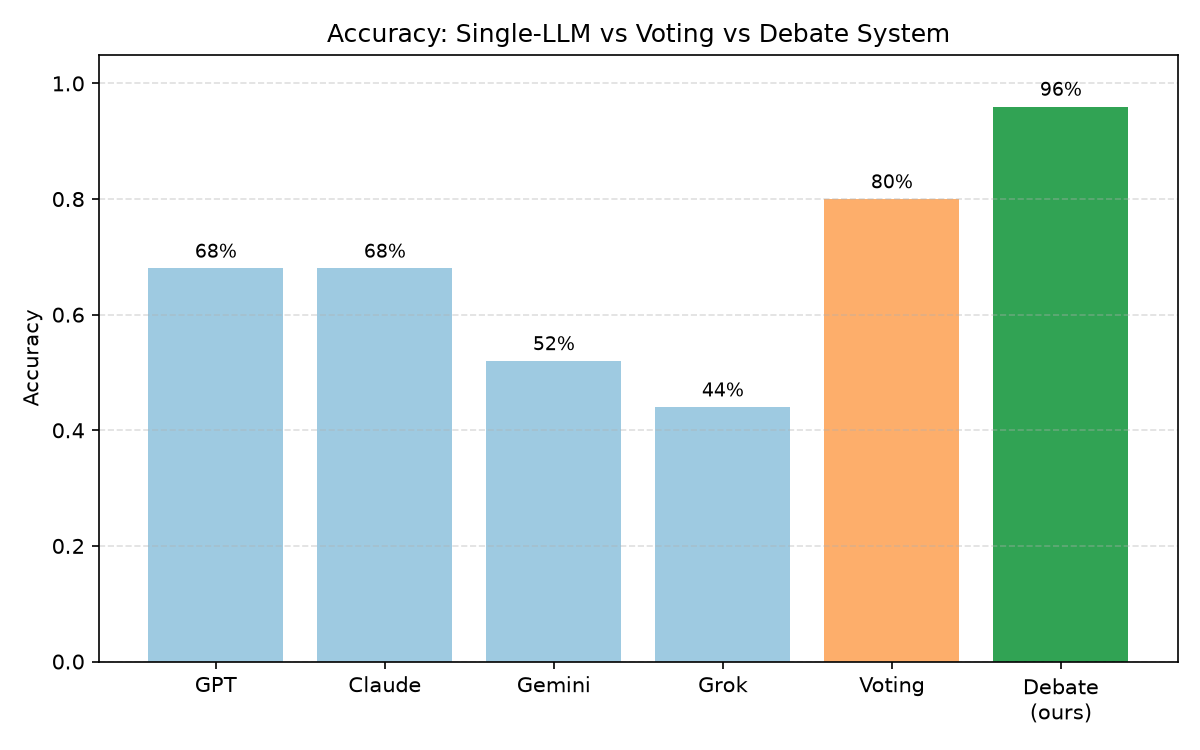

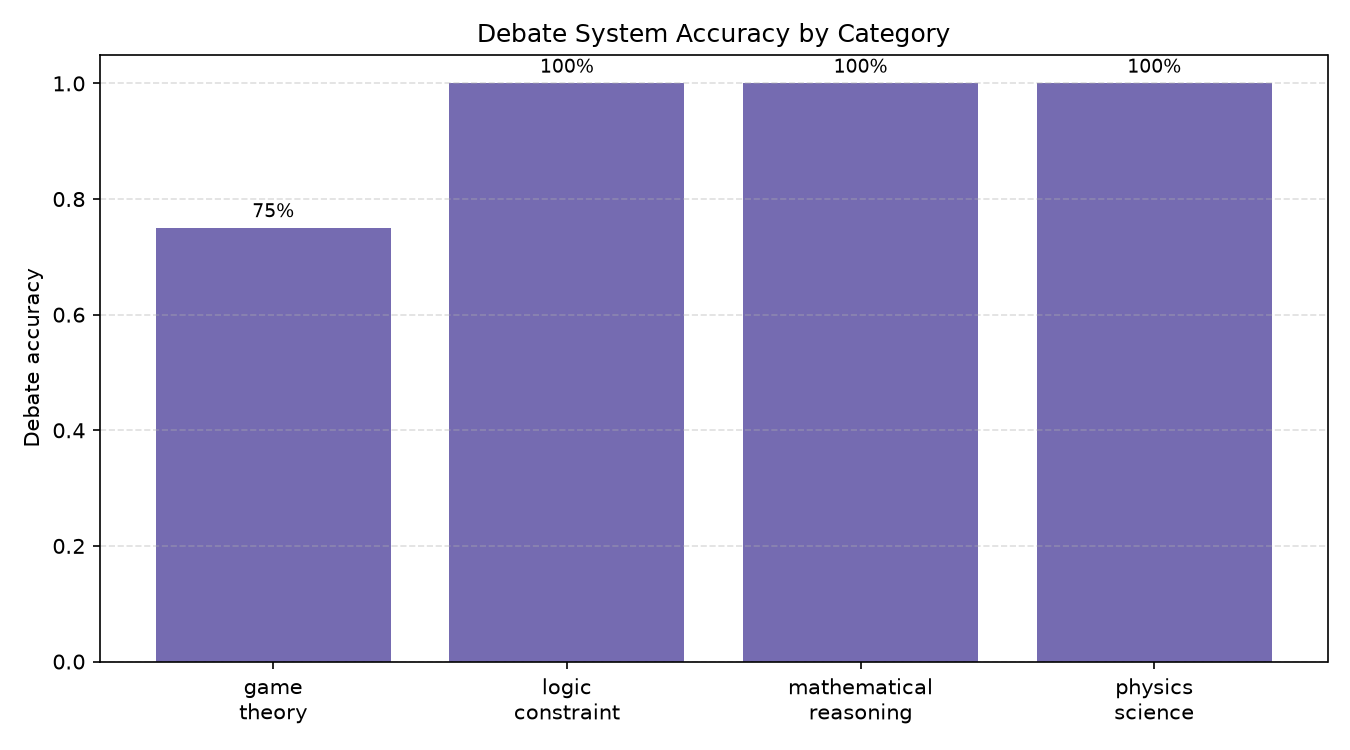

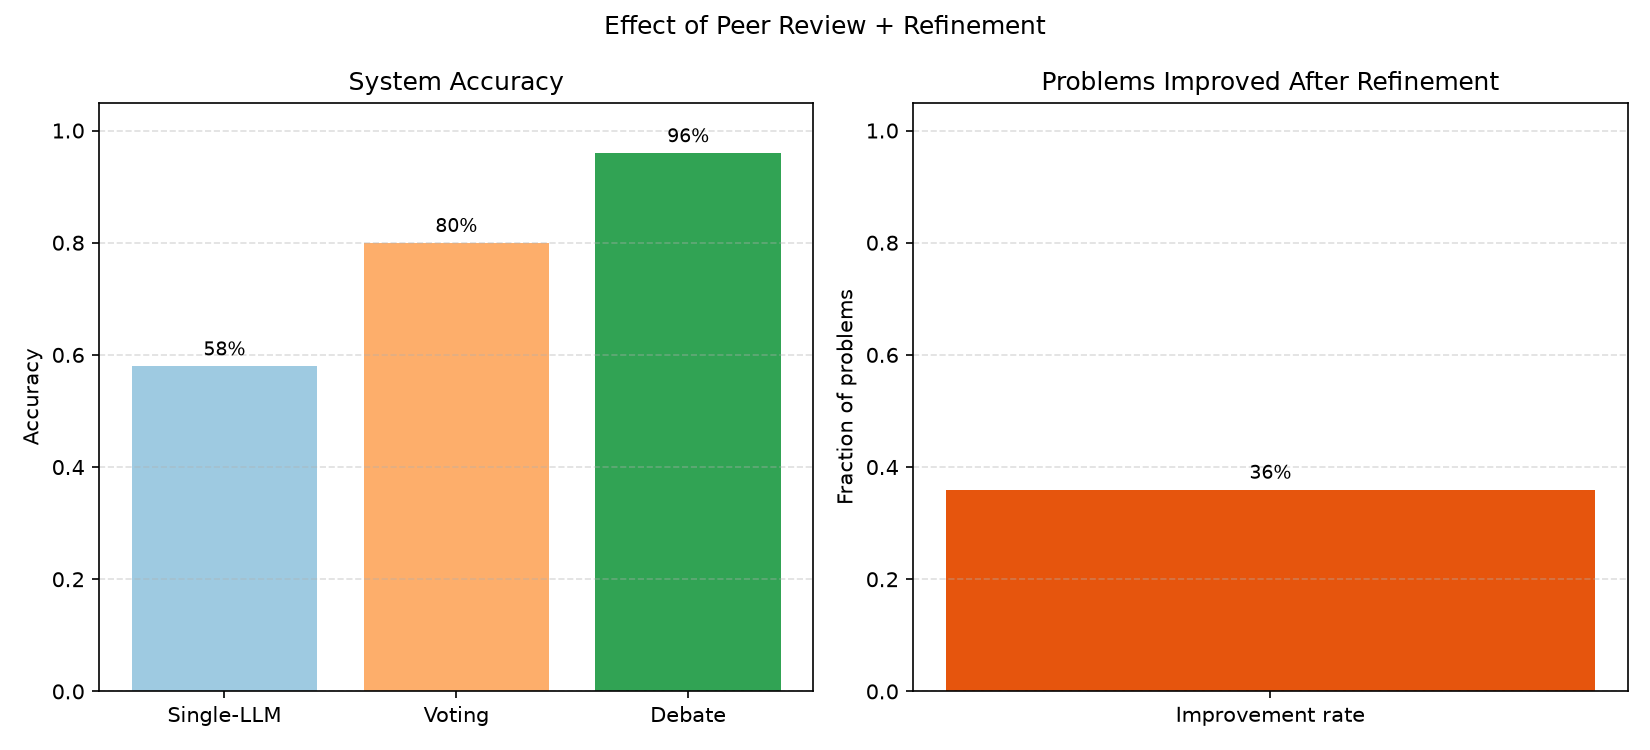

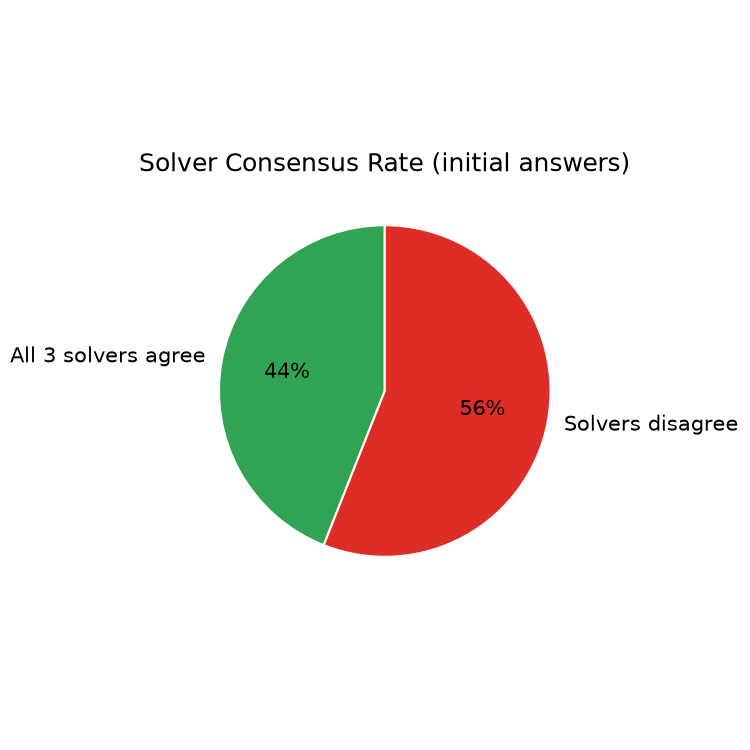

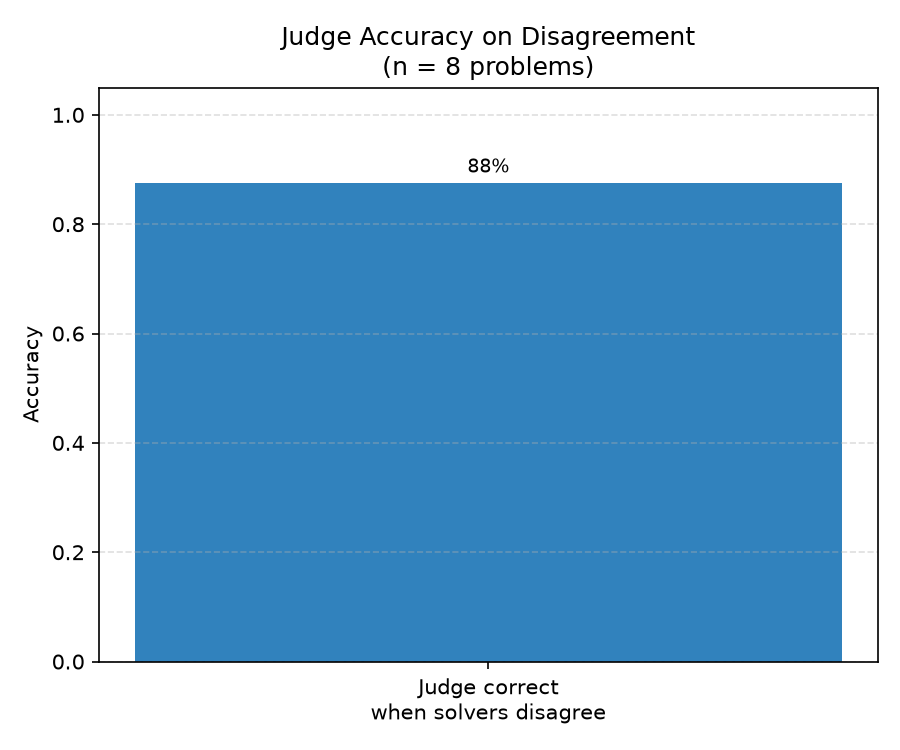

In [5]:
from IPython.display import Image, display
for p in paths:
    display(Image(filename=str(p)))